In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from scipy.stats import pearsonr
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error as rmse

import matplotlib
matplotlib.rcParams['font.serif'] = "Palatino"
matplotlib.rcParams['font.family'] = "serif"

# plt.rc('font', size=10)          # controls default text sizes
plt.rc('axes', titlesize=20)     # fontsize of the axes title
plt.rc('axes', labelsize=20)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=15)    # fontsize of the tick labels
plt.rc('ytick', labelsize=15)    # fontsize of the tick labels
plt.rc('legend', fontsize=15)    # legend fontsize

In [2]:
hb00 = pd.read_csv('_data/Hyperbolic_rec_00.csv', index_col=0)
hb02 = pd.read_csv('_data/Hyperbolic_rec_02.csv', index_col=0)
hb04 = pd.read_csv('_data/Hyperbolic_rec_04.csv', index_col=0)
hb06 = pd.read_csv('_data/Hyperbolic_rec_06.csv', index_col=0)
hb08 = pd.read_csv('_data/Hyperbolic_rec_08.csv', index_col=0)
hb10 = pd.read_csv('_data/Hyperbolic_rec_10.csv', index_col=0)

ex00 = pd.read_csv('_data/Exponential_rec_00.csv', index_col=0)
ex02 = pd.read_csv('_data/Exponential_rec_02.csv', index_col=0)
ex04 = pd.read_csv('_data/Exponential_rec_04.csv', index_col=0)
ex06 = pd.read_csv('_data/Exponential_rec_06.csv', index_col=0)
ex08 = pd.read_csv('_data/Exponential_rec_08.csv', index_col=0)
ex10 = pd.read_csv('_data/Exponential_rec_10.csv', index_col=0)

In [3]:
recovery = {
    'Hyperbolic':  [hb10, hb08, hb06, hb04, hb02, hb00],
    'Exponential': [ex10, ex08, ex06, ex04, ex02, ex00]
}

color = {'a': '#ffd166',
         'lambda': '#ef476f',
         'delta': '#26547c'}

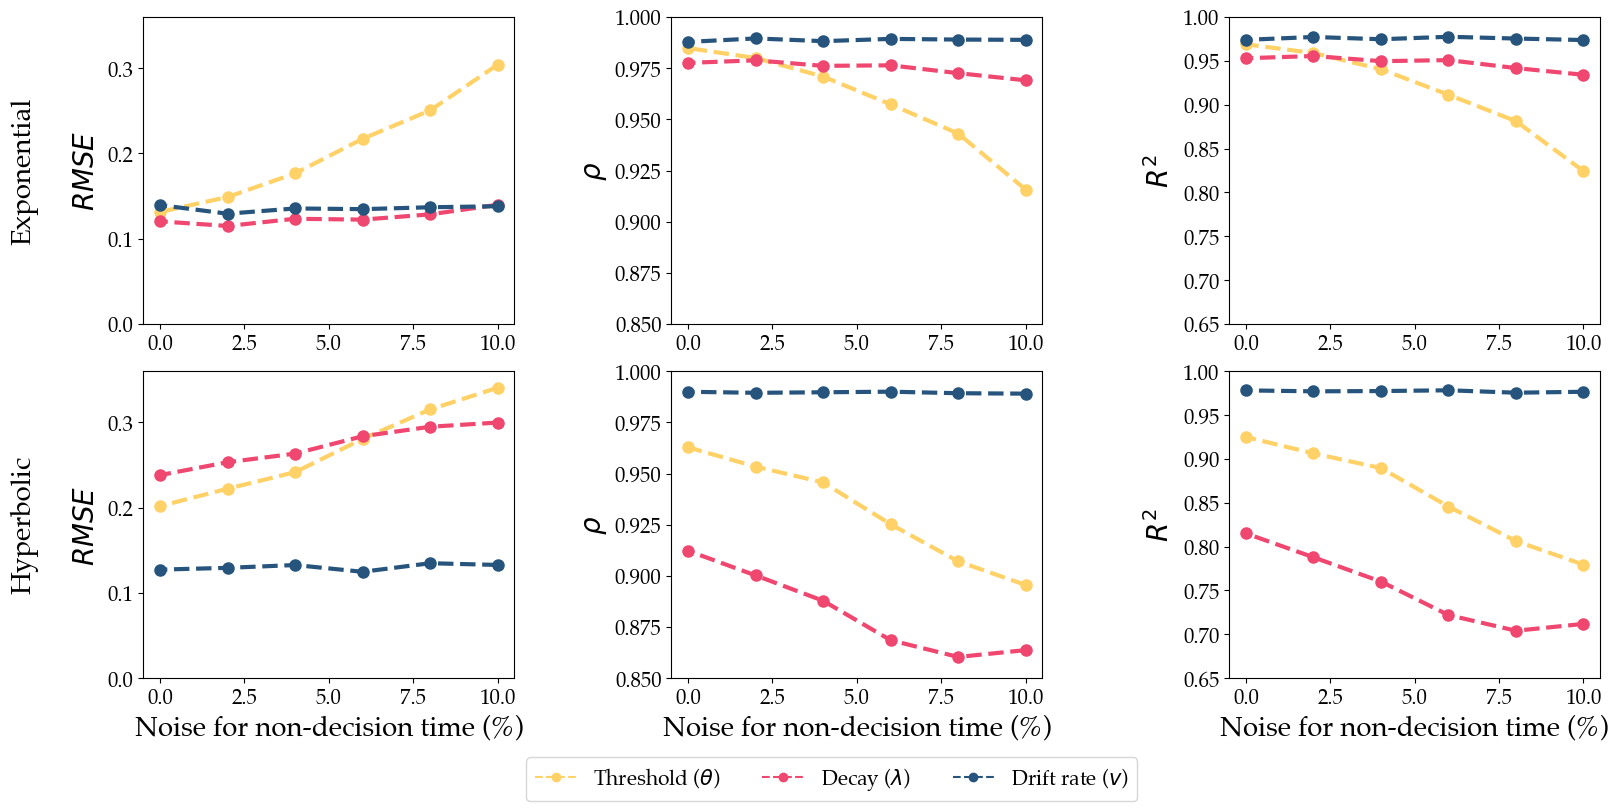

In [4]:
plt.figure(figsize=(16, 8), layout='constrained')

plt.subplot(2, 3, 1)
for prms in ['a', 'lambda', 'delta']:
    plt.plot([10, 8, 6, 4, 2, 0], 
             [rmse(recovery['Exponential'][i]['{}_true'.format(prms)],
                   recovery['Exponential'][i]['{}_estimate'.format(prms)]) for i in range(6)],
             '--', marker='o', markersize=8, linewidth=3, c=color[prms])
plt.ylim([0, 0.36])
plt.ylabel('Exponential\n\n$RMSE$');

plt.subplot(2, 3, 2)
for prms in ['a', 'lambda', 'delta']:
    plt.plot([10, 8, 6, 4, 2, 0], 
             [pearsonr(recovery['Exponential'][i]['{}_true'.format(prms)],
                       recovery['Exponential'][i]['{}_estimate'.format(prms)])[0] for i in range(6)],
             '--', marker='o', markersize=8, linewidth=3, c=color[prms])
plt.ylim([0.85, 1])
plt.ylabel(r'$\rho$')

plt.subplot(2, 3, 3)
for prms in ['a', 'lambda', 'delta']:
    plt.plot([10, 8, 6, 4, 2, 0], 
             [r2_score(recovery['Exponential'][i]['{}_true'.format(prms)],
                       recovery['Exponential'][i]['{}_estimate'.format(prms)]) for i in range(6)],
             '--', marker='o', markersize=8, linewidth=3, c=color[prms])
plt.ylim([0.65, 1])
plt.ylabel(r'$R^2$')

plt.subplot(2, 3, 4)
for prms in ['a', 'lambda', 'delta']:
    plt.plot([10, 8, 6, 4, 2, 0], 
             [rmse(recovery['Hyperbolic'][i]['{}_true'.format(prms)],
                   recovery['Hyperbolic'][i]['{}_estimate'.format(prms)]) for i in range(6)],
             '--', marker='o', markersize=8, linewidth=3, c=color[prms])
plt.ylim([0, 0.36])
plt.ylabel('Hyperbolic\n\n$RMSE$')
plt.xlabel('Noise for non-decision time (%)');

plt.subplot(2, 3, 5)
for prms in ['a', 'lambda', 'delta']:
    plt.plot([10, 8, 6, 4, 2, 0], 
             [pearsonr(recovery['Hyperbolic'][i]['{}_true'.format(prms)],
                       recovery['Hyperbolic'][i]['{}_estimate'.format(prms)])[0] for i in range(6)],
             '--', marker='o', markersize=8, linewidth=3, c=color[prms])
plt.ylim([0.85, 1])
plt.ylabel(r'$\rho$')
plt.xlabel('Noise for non-decision time (%)');

handles, labels = plt.gca().get_legend_handles_labels()

threshold = Line2D([0], [0], label=r'Threshold ($\theta$)', color='#ffd166', marker='o', linestyle='--')
decay = Line2D([0], [0], label='Decay ($\lambda$)', color='#ef476f', marker='o', linestyle='--')
drift = Line2D([0], [0], label='Drift rate ($v$)', color='#26547c', marker='o', linestyle='--')
handles.extend([threshold, decay, drift])

plt.legend(handles=handles, loc=(-0.39, -.4), ncol=3);
    
plt.subplot(2, 3, 6)
for prms in ['a', 'lambda', 'delta']:
    plt.plot([10, 8, 6, 4, 2, 0], 
             [r2_score(recovery['Hyperbolic'][i]['{}_true'.format(prms)],
                       recovery['Hyperbolic'][i]['{}_estimate'.format(prms)]) for i in range(6)],
             '--', marker='o', markersize=8, linewidth=3, c=color[prms]);
plt.ylim([0.65, 1])
plt.ylabel(r'$R^2$')
plt.xlabel('Noise for non-decision time (%)');

plt.savefig('ndt_tradeoff.pdf', 
            transparent=True, 
            dpi=600, 
            bbox_inches='tight');